# Modelado y evaluación de volatilidad del SPY

## Objetivo

En este notebook se evalúan distintos modelos para predecir la volatilidad futura del ETF `SPY` a partir de las variables construidas en la etapa de preparación.

El problema se formula como una tarea supervisada de regresión sobre una serie temporal financiera. Para cada fecha `t`, los modelos usan información disponible hasta ese momento y buscan anticipar una medida de volatilidad asociada al horizonte futuro de 21 días hábiles.

## Estrategia general

Se comparan modelos de complejidad creciente:

- baseline persistente;
- regresión lineal con selección de variables;
- Random Forest;
- red recurrente tipo LSTM.

La evaluación respeta la separación temporal entre entrenamiento, validación y prueba para evitar fuga de información futura. Las métricas principales son MAE y RMSE, que permiten mirar tanto el error promedio como la penalización por errores grandes.


In [53]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_predict

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [54]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
TICKER = "SPY"

# re-levantamos los splits procesados
data = {
    split:pd.read_csv(PROCESSED_DIR / f"{TICKER.lower()}_{split}.csv", index_col="Date", parse_dates=["Date"])
    for split in ("train","validation","test")
}

# corroboramos datos del EDA
split_summary = pd.DataFrame(
    [{
        "subset": split,
        "filas": len(split_df),
        "fecha_inicio": split_df.index.min(),
        "fecha_fin": split_df.index.max(),
    }
    for split, split_df in data.items()
    ]
).set_index("subset")

display(split_summary)

,filas,fecha_inicio,fecha_fin
subset,,,
train,2706,2010-04-06,2020-12-31
validation,753,2021-01-04,2023-12-29
test,501,2024-01-02,2025-12-30


In [55]:
np.corrcoef(data["train"]["volatility_21d"].values[:-21], data["train"]["volatility_21d"].shift(-21).values[:-21])

array([[1.        , 0.50102554],
       [0.50102554, 1.        ]])

## Definición del target

El target se define como `volatility_21d` desplazada 21 días hacia adelante. Es decir, para cada fecha `t`, el modelo utiliza las variables disponibles hasta `t` para predecir el valor de la volatilidad móvil de 21 días observado en `t+21`.

Esta decisión evita usar como objetivo el valor del día siguiente. Dos ventanas móviles consecutivas de 21 días comparten 20 observaciones, por lo que su correlación es mecánicamente muy alta. Al desplazar una ventana completa, el problema predictivo es más exigente y menos redundante.

La comparación de correlaciones con desplazamiento de 1 y 21 días permite mostrar este punto empíricamente antes de entrenar los modelos.


In [56]:
# correlacion con día siguiente
shift_days = -1


print(f"Shift de {abs(shift_days)} días")
for split, df in data.items():
    s = df.volatility_21d
    value = s.corr(s.shift(shift_days))
    print(f"{split: >10}: {value.round(3)}")

Shift de 1 días
     train: 0.993
validation: 0.99
      test: 0.986


In [57]:
shift_days = -21


print(f"Shift de {abs(shift_days)} días")
for split, df in data.items():
    s = df.volatility_21d
    value = s.corr(s.shift(shift_days))
    print(f"{split: >10}: {value.round(3)}")

Shift de 21 días
     train: 0.501
validation: 0.684
      test: 0.287


In [58]:
for split, df in data.items():
    df["target"] = df.volatility_21d.shift(-21)
    # hay que eliminar las últimas 21 filas
    df.dropna(inplace=True)

In [59]:
data["train"]

,Adj_Close,Close,High,Low,Open,Volume,price_base,return_simple,return_log,return_abs,volatility_5d,mean_abs_return_5d,volatility_21d,mean_abs_return_21d,volatility_63d,mean_abs_return_63d,return_log_lag_1,return_log_lag_2,return_log_lag_5,return_log_lag_10,year,month,weekday,target
Date,,,,,,,,,,,,,,,,,,,,,,,,
2010-04-06,89.435524,119.040001,119.250000,118.290001,118.419998,110384200,89.435524,0.002358,0.002355,0.002355,0.004680,0.004276,0.004129,0.003684,0.008771,0.006419,0.008116,0.006814,0.006327,0.005331,2010,4,1,0.011099
2010-04-07,88.924637,118.360001,119.360001,117.809998,118.800003,184576300,88.924637,-0.005712,-0.005729,0.005729,0.006105,0.005286,0.004458,0.003949,0.008807,0.006468,0.002355,0.008116,0.000682,0.007009,2010,4,2,0.013198
2010-04-08,89.232674,118.769997,118.970001,117.599998,117.949997,158704000,89.232674,0.003464,0.003458,0.003458,0.005421,0.005294,0.004471,0.004034,0.008813,0.006511,-0.005729,0.002355,-0.003413,-0.004867,2010,4,3,0.013413
2010-04-09,89.818672,119.550003,119.599998,118.800003,119.019997,133006500,89.818672,0.006567,0.006546,0.006546,0.005375,0.005241,0.004552,0.004134,0.008833,0.006548,0.003458,-0.005729,0.006814,-0.001627,2010,4,4,0.016698
2010-04-12,89.961426,119.739998,120.050003,119.559998,119.699997,110279000,89.961426,0.001589,0.001588,0.001588,0.004533,0.003935,0.004527,0.004011,0.008828,0.006521,0.006546,0.003458,0.008116,-0.000600,2010,4,0,0.016687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-24,336.698578,363.220001,363.809998,359.290009,360.209991,62415900,336.698578,0.016114,0.015985,0.015985,0.011095,0.009029,0.013581,0.011282,0.013250,0.010779,0.005977,-0.006872,-0.005393,-0.001468,2020,11,1,0.005404
2020-11-25,336.179443,362.660004,363.160004,361.480011,363.130005,45330900,336.179443,-0.001542,-0.001543,0.001543,0.008595,0.006916,0.013541,0.011191,0.013252,0.010769,0.015985,0.005977,-0.012108,0.007401,2020,11,2,0.005616
2020-11-27,337.115631,363.670013,364.179993,362.579987,363.839996,28514100,337.115631,0.002785,0.002781,0.002781,0.008592,0.006631,0.010365,0.009667,0.013234,0.010711,-0.001543,0.015985,0.004202,-0.009748,2020,11,4,0.005653


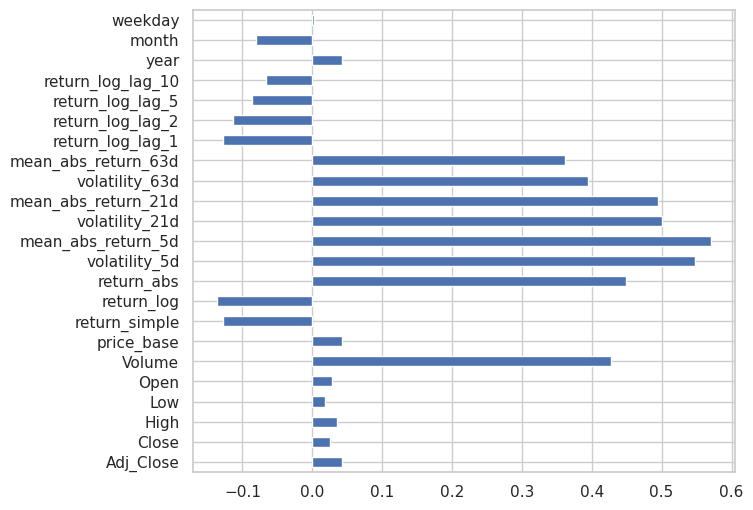

In [60]:
# observamos la correlación de cada variable
(
    data["train"]
    .corr()
    ["target"]
    .drop(index="target")
    .plot(kind="barh", figsize=(7,6))
)
plt.show()

La correlación con el target muestra que las variables basadas en ventanas móviles de volatilidad y magnitud de retornos concentran mayor información predictiva que los retornos diarios aislados.

Esto es consistente con el fenómeno de `volatility clustering`: los retornos pueden tener baja autocorrelación lineal, pero la magnitud de los movimientos y la volatilidad suelen presentar mayor persistencia temporal.


In [61]:
def eval_preds(y_true, y_pred):
    eval_fs = {
        "MAE":mean_absolute_error, 
        "RMSE":root_mean_squared_error,
    }

    return {name:f(y_true, y_pred) for name, f in eval_fs.items()}

eval_preds([1,1],[1,2])

{'MAE': 0.5, 'RMSE': 0.7071067811865476}

## Baseline persistente

Se utiliza como baseline una predicción persistente: la volatilidad actual de 21 días (`volatility_21d`) se usa como pronóstico de la volatilidad futura.

Este baseline es importante porque la volatilidad suele tener persistencia temporal. Por lo tanto, no es un punto de comparación trivial: cualquier modelo más complejo debería justificar su uso mejorando esta referencia simple.


In [62]:
test_preds_baseline = data["test"].volatility_21d
test_target = data["test"].target

eval_preds(test_target, test_preds_baseline)

{'MAE': 0.004002050363663327, 'RMSE': 0.006499427591043783}

El modelo persistente suele ser difícil de superar en series de volatilidad, porque aprovecha directamente la continuidad temporal de períodos tranquilos y períodos turbulentos.


In [63]:
test_metrics_df = pd.DataFrame(eval_preds(test_target, test_preds_baseline), index=["constant"]).T
test_metrics_df

,constant
MAE,0.004002
RMSE,0.006499


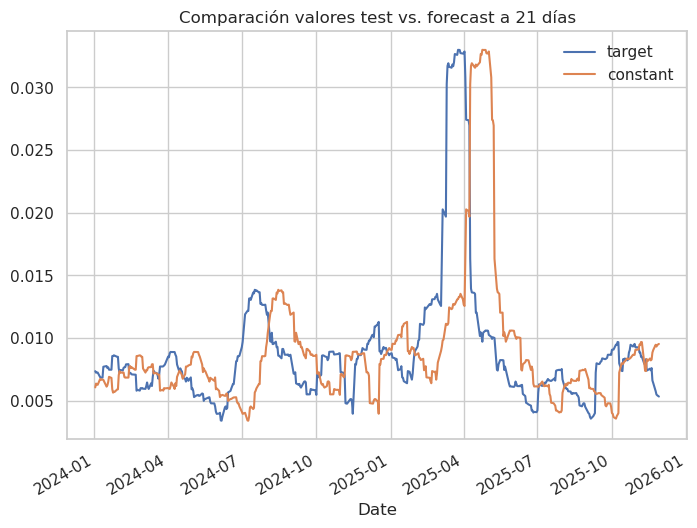

In [64]:
# ploteo pronóstico vs realidad
preds_test_df = data["test"][["target"]].copy()
preds_test_df["constant"] = test_preds_baseline

ax = preds_test_df.plot(figsize=(8,6))
ax.set_title("Comparación valores test vs. forecast a 21 días")
#sns.lineplot(preds_test_df)
plt.show()

## Modelo lineal con selección de variables

El modelo lineal asume que una combinación lineal de las variables generadas en el notebook anterior puede aproximar la volatilidad futura.

Como no todas las variables necesariamente aportan señal, se aplica `backward elimination` usando el conjunto de validación como criterio de selección. El objetivo de esta etapa no es maximizar desempeño sobre test, sino elegir un subconjunto de predictores antes de la evaluación final.


In [65]:
from collections.abc import Callable

def backward_elimination(
    model_factory: Callable
):
    # data splits son fijos
    X_train = data["train"].drop(columns="target")
    y_train = data["train"].target

    X_val = data["validation"].drop(columns="target")
    y_val = data["validation"].target

    features = list(X_train.columns)

    best_model = model_factory()

    best_model.fit(
        X_train[features],
        y_train,
    )

    best_score = mean_absolute_error(
        y_val,
        best_model.predict(X_val[features]),
    )

    history = [{
        "removed": "",
        "score": best_score,
        "n_features": len(features),
    }]

    while len(features) > 1:
        candidates = []

        for feature_to_remove in features:
            candidate_features = [f for f in features if f != feature_to_remove]

            model = model_factory()

            model.fit(
                X_train[candidate_features],
                y_train,
            )

            score = mean_absolute_error(
                y_val,
                model.predict(X_val[candidate_features]),
            )

            candidates.append(
                {
                    "removed": feature_to_remove,
                    "features": candidate_features,
                    "score": score,
                    "model": model,
                }
            )

        candidates = sorted(
            candidates,
            key=lambda x: x["score"],
        )

        best_candidate = candidates[0]

        if best_candidate["score"] >= best_score:
            break

        print(
            f"Removing {best_candidate['removed']} "
            f"({best_score:.6f} -> {best_candidate['score']:.6f})"
        )

        features = best_candidate["features"]
        best_score = best_candidate["score"]
        best_model = best_candidate["model"]

        history.append(
            {
                "removed": best_candidate["removed"],
                "score": best_candidate["score"],
                "n_features": len(features),
            }
        )

    return {
        "features": features,
        "score": best_score,
        "model": best_model,
        "history": pd.DataFrame(history),
    }

In [66]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


def linear_factory():
    return make_pipeline(StandardScaler(), LinearRegression())

res_linear = backward_elimination(linear_factory)

Removing year (0.009253 -> 0.003846)
Removing Volume (0.003846 -> 0.003166)
Removing High (0.003166 -> 0.003062)
Removing month (0.003062 -> 0.003000)
Removing mean_abs_return_21d (0.003000 -> 0.002988)
Removing return_log_lag_10 (0.002988 -> 0.002987)
Removing return_log (0.002987 -> 0.002987)
Removing Adj_Close (0.002987 -> 0.002987)
Removing price_base (0.002987 -> 0.002527)
Removing return_abs (0.002527 -> 0.002523)
Removing weekday (0.002523 -> 0.002522)


<Axes: title={'center': 'Mejora de MAE en validación por backward elimination'}, xlabel='Variable removida', ylabel='MAE'>

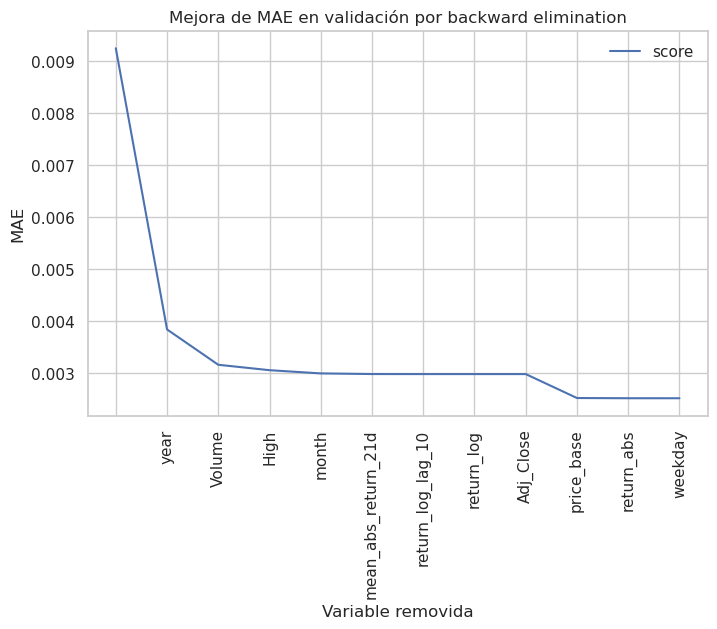

In [67]:
def plot_improvement(res):
    hist = res["history"]
    ax = hist.plot(x="removed",y="score", rot=90, figsize=(8,5))
    ax.set_xticks(range(len(hist)))
    ax.set_xticklabels(
        hist["removed"],
        rotation=90,
    )
    ax.set_ylabel("MAE")
    ax.set_xlabel("Variable removida")
    ax.set_title("Mejora de MAE en validación por backward elimination")
    return ax

plot_improvement(res_linear)

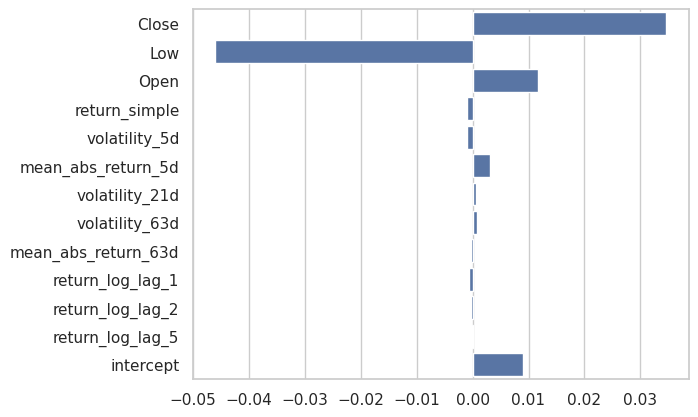

In [68]:
# vemos los coeficientes de cada variable
sns.barplot(x=res_linear["model"][-1].coef_.tolist()+[res_linear["model"][-1].intercept_], y=res_linear["features"]+["intercept"])
plt.show()

In [69]:
test_preds_linear = res_linear["model"].predict(data["test"][res_linear["features"]])

preds_test_df["linear"] = test_preds_linear
test_metrics_df["linear"] = eval_preds(test_target, test_preds_linear)
test_metrics_df

,constant,linear
MAE,0.004002,0.003687
RMSE,0.006499,0.005410


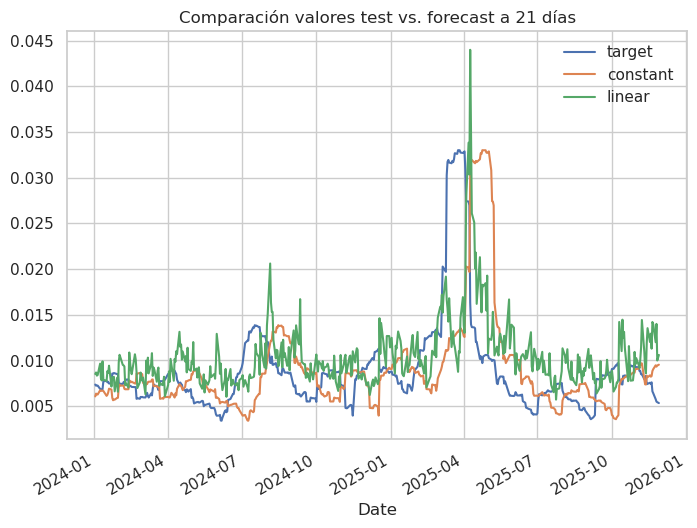

In [70]:
# ploteo pronóstico vs realidad
ax = preds_test_df.plot(figsize=(8,6))
ax.set_title("Comparación valores test vs. forecast a 21 días")
plt.show()

En el modelo lineal, los coeficientes permiten interpretar qué variables aportan más peso relativo después del escalado. La presencia de variables de precio, retornos rezagados y medidas móviles sugiere que el modelo combina información de nivel, dinámica reciente y escala de variabilidad.

Frente al baseline, el modelo lineal es especialmente útil como referencia intermedia: mantiene baja complejidad, es interpretable y permite evaluar cuánto se gana antes de pasar a modelos no lineales.


## Random Forest

Random Forest permite capturar relaciones no lineales e interacciones entre variables sin requerir reescalamiento. A diferencia del modelo lineal, no impone una forma funcional simple entre predictores y target.

Su principal limitación en este contexto es que los modelos basados en árboles no extrapolan bien fuera del rango observado durante entrenamiento. Sus predicciones se construyen por regiones del espacio de variables, lo que puede dificultar la anticipación de episodios de volatilidad extremos o cambios bruscos de régimen.


In [71]:
from sklearn.ensemble import RandomForestRegressor

def rf_factory():
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1,
    )

res_rf_bw_elim = backward_elimination(rf_factory)

Removing High (0.014962 -> 0.013810)
Removing mean_abs_return_63d (0.013810 -> 0.012824)
Removing volatility_63d (0.012824 -> 0.010579)
Removing month (0.010579 -> 0.003985)
Removing mean_abs_return_21d (0.003985 -> 0.003600)
Removing year (0.003600 -> 0.003394)
Removing volatility_21d (0.003394 -> 0.003229)
Removing Volume (0.003229 -> 0.003134)
Removing Close (0.003134 -> 0.003100)
Removing Adj_Close (0.003100 -> 0.003076)
Removing Open (0.003076 -> 0.003065)


<Axes: title={'center': 'Mejora de MAE en validación por backward elimination'}, xlabel='Variable removida', ylabel='MAE'>

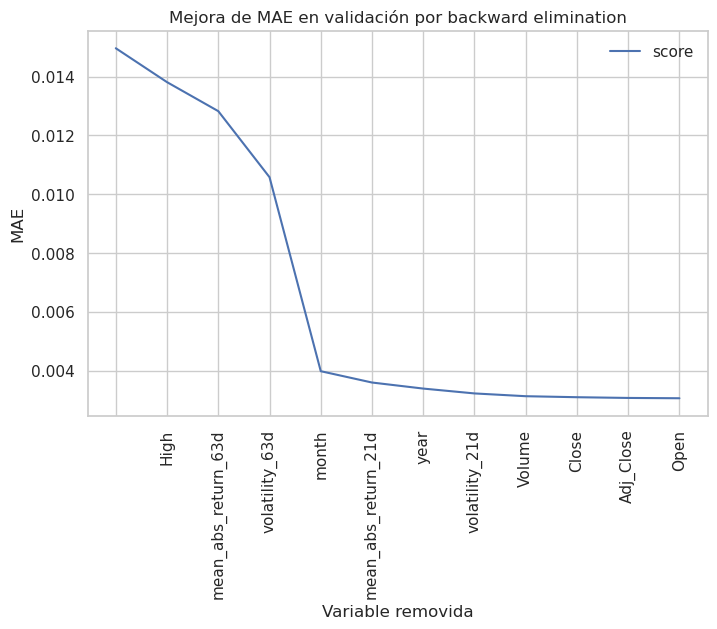

In [72]:
plot_improvement(res_rf_bw_elim)

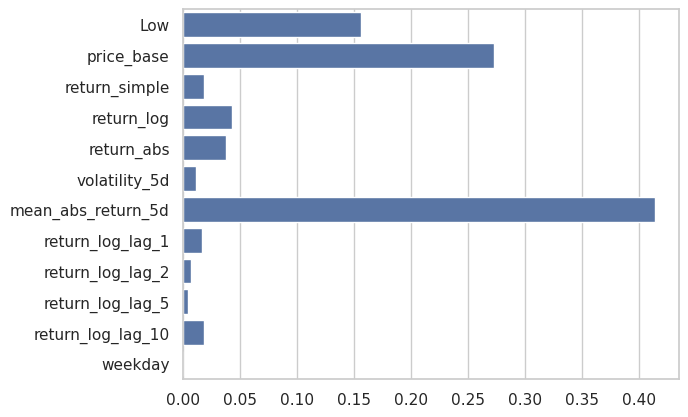

In [73]:
# vemos las importancias de cada variable
sns.barplot(x=res_rf_bw_elim["model"][-1].feature_importances_, y=res_rf_bw_elim["features"])
plt.show()

In [74]:
test_preds_rf = res_rf_bw_elim["model"].predict(data["test"][res_rf_bw_elim["features"]])

preds_test_df["rf"] = test_preds_rf
test_metrics_df["rf"] = eval_preds(test_target, test_preds_rf)
test_metrics_df

,constant,linear,rf
MAE,0.004002,0.003687,0.003322
RMSE,0.006499,0.005410,0.006812


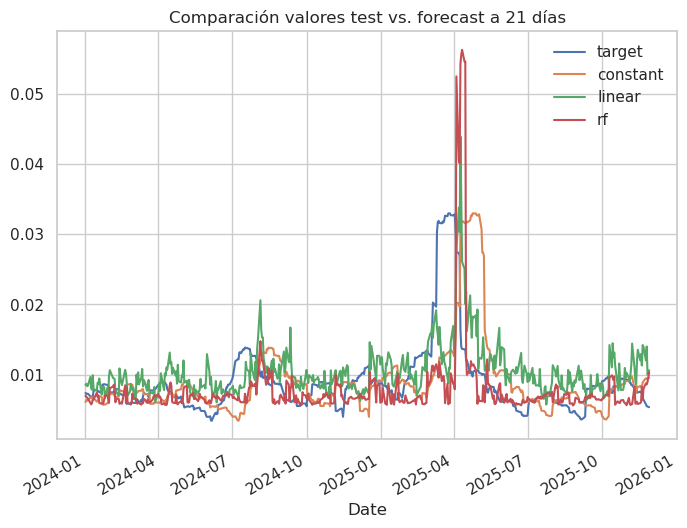

In [75]:
# ploteo pronóstico vs realidad
ax = preds_test_df.plot(figsize=(8,6))
ax.set_title("Comparación valores test vs. forecast a 21 días")
plt.show()

In [76]:
# variables compartidas y de cada uno
vars_linear = set(res_linear["features"])
vars_rf = set(res_rf_bw_elim["features"])

print("Compartidas:", vars_linear & vars_rf)

print("Solo lineal:", vars_linear - vars_rf)
print("Solo RF:",vars_rf - vars_linear)

Compartidas: {'Low', 'return_log_lag_2', 'return_log_lag_1', 'mean_abs_return_5d', 'volatility_5d', 'return_log_lag_5', 'return_simple'}
Solo lineal: {'Close', 'volatility_21d', 'mean_abs_return_63d', 'Open', 'volatility_63d'}
Solo RF: {'price_base', 'weekday', 'return_abs', 'return_log_lag_10', 'return_log'}


Random Forest mejora el error absoluto promedio respecto del baseline, pero debe analizarse junto con el RMSE. Si el MAE baja y el RMSE sube, el modelo está reduciendo errores frecuentes pero cometiendo algunos errores grandes.

Esta diferencia es relevante en volatilidad financiera, porque los períodos de estrés son justamente los más difíciles de anticipar y los que más pesan en métricas cuadráticas.


## Red recurrente LSTM

La LSTM se incorpora como modelo secuencial. A diferencia de los modelos anteriores, recibe ventanas de observaciones pasadas y puede aprender patrones temporales dentro de cada secuencia.

Se usan variables de escala razonable vinculadas a retornos y volatilidad. Además, se aplica `EarlyStopping` para conservar los pesos con mejor desempeño en validación y se utiliza una salida `softplus` para evitar predicciones negativas de volatilidad.


In [77]:
# variables de escala razonable, sin lags
features_net = [
    "return_log",
    "return_abs",
    "volatility_5d",
    "volatility_21d",
    "volatility_63d",
]

In [78]:
def make_sequences(X, y, lookback=21):
    X_seq = []
    y_seq = []

    for i in range(lookback - 1, len(X)):
        X_seq.append(
            X[i - lookback + 1 : i + 1]
        )
        y_seq.append(
            y.iloc[i]
        )

    return (
        np.array(X_seq),
        np.array(y_seq),
    )

In [79]:
ss = StandardScaler()
X_train = ss.fit_transform(data["train"].drop(columns="target")[features_net])
y_train = data["train"].target

X_val = ss.transform(data["validation"].drop(columns="target")[features_net])
y_val = data["validation"].target

X_test_rnn = ss.transform(data["test"].drop(columns="target")[features_net])
y_test_rnn = data["test"].target

In [80]:
LOOKBACK=21

X_train_seq, y_train_seq = make_sequences(X_train, y_train, LOOKBACK)
X_val_seq, y_val_seq = make_sequences(X_val, y_val, LOOKBACK)
X_test_seq, y_test_seq = make_sequences(X_test_rnn, y_test_rnn, LOOKBACK)

In [81]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
import os
os.environ["KERAS_BACKEND"] = "torch"
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping
# model = Sequential([
#     LSTM(32),
#     Dense(1),
# ])

# model.compile(
#     optimizer="adam",
#     loss="mae",
# )
model = Sequential([
    LSTM(16),
    Dense(1, activation="softplus"),
]) 
model.compile(
    optimizer="adam",
    loss="mae",
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)


model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
)

cuda
NVIDIA GeForce RTX 5060 Ti
Epoch 1/100
  1/167 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - loss: 0.6728

/home/seba/miniconda3/lib/python3.13/site-packages/keras/src/backend/torch/rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  outputs, (h_n, c_n) = torch._VF.lstm(


167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1865 - val_loss: 0.0042
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0043 - val_loss: 0.0031
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0033 - val_loss: 0.0029
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 7/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 8/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 9/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 10/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 11/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 12/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 

In [82]:
preds_test_df

,target,constant,linear,rf
Date,,,,
2024-01-02,0.007359,0.006066,0.008521,0.006980
2024-01-03,0.007238,0.006369,0.008683,0.006793
2024-01-04,0.007255,0.006281,0.008340,0.006716
2024-01-05,0.007251,0.006272,0.008406,0.006548
2024-01-08,0.006885,0.006731,0.009646,0.005962
...,...,...,...,...
2025-11-21,0.006417,0.009041,0.013973,0.007970
2025-11-24,0.005766,0.009465,0.011995,0.008737
2025-11-25,0.005498,0.009324,0.013996,0.008574


In [83]:
test_preds_rnn = model.predict(X_test_seq).flatten()

#preds_test_df["rnn"] = test_preds_rnn

preds_test_df.loc[
    preds_test_df.index[LOOKBACK - 1:],
    "rnn"
] = test_preds_rnn

test_metrics_df["rnn"] = eval_preds(y_test_seq, test_preds_rnn)
test_metrics_df

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/home/seba/miniconda3/lib/python3.13/site-packages/keras/src/backend/torch/rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  outputs, (h_n, c_n) = torch._VF.lstm(


,constant,linear,rf,rnn
MAE,0.004002,0.003687,0.003322,0.003197
RMSE,0.006499,0.005410,0.006812,0.005372


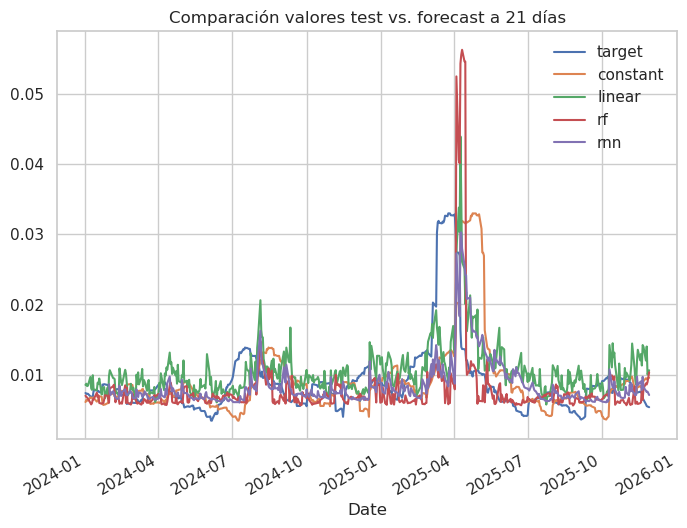

In [91]:
# ploteo pronóstico vs realidad
ax = preds_test_df.plot(figsize=(8,6))
ax.set_title("Comparación valores test vs. forecast a 21 días")
plt.show()

Con la configuración final, la LSTM logra mejorar al baseline y competir favorablemente contra los modelos anteriores. Esto sugiere que existe información secuencial útil en las ventanas recientes de retornos y volatilidad.

Aun así, la mejora debe interpretarse con cuidado: la red tiene mayor costo computacional y menor interpretabilidad que el modelo lineal. Por eso conviene comparar no solo el mejor valor de una métrica, sino también la estabilidad de los errores y el comportamiento en períodos específicos del test.


## Comparación final de resultados

La tabla `test_metrics_df` resume las métricas calculadas durante el flujo de modelado. Para que la comparación visual sea estrictamente equivalente entre modelos, también se calcula una versión alineada sobre las fechas donde existen predicciones de todos los modelos. Esto es importante porque la LSTM pierde las primeras observaciones del conjunto de test al construir secuencias con `lookback`.


In [99]:
model_cols = ["constant", "linear", "rf", "rnn"]

aligned_preds_df = preds_test_df[["target", *model_cols]].dropna().copy()

aligned_metrics_df = pd.DataFrame(
    {
        model_name: eval_preds(aligned_preds_df["target"], aligned_preds_df[model_name])
        for model_name in model_cols
    }
)

baseline_aligned = aligned_metrics_df["constant"]
aligned_improvement_df = (1 - aligned_metrics_df.div(baseline_aligned, axis=0)) * 100

print("Métricas sobre fechas comunes a todos los modelos")
display(aligned_metrics_df)

print("Mejora porcentual respecto del baseline persistente")
display(aligned_improvement_df)


Métricas sobre fechas comunes a todos los modelos


,constant,linear,rf,rnn
MAE,0.004116,0.003797,0.003414,0.003197
RMSE,0.006630,0.005519,0.006953,0.005372


Mejora porcentual respecto del baseline persistente


,constant,linear,rf,rnn
MAE,0.000000,7.743844,17.052470,22.316998
RMSE,0.000000,16.759544,-4.873561,18.972019


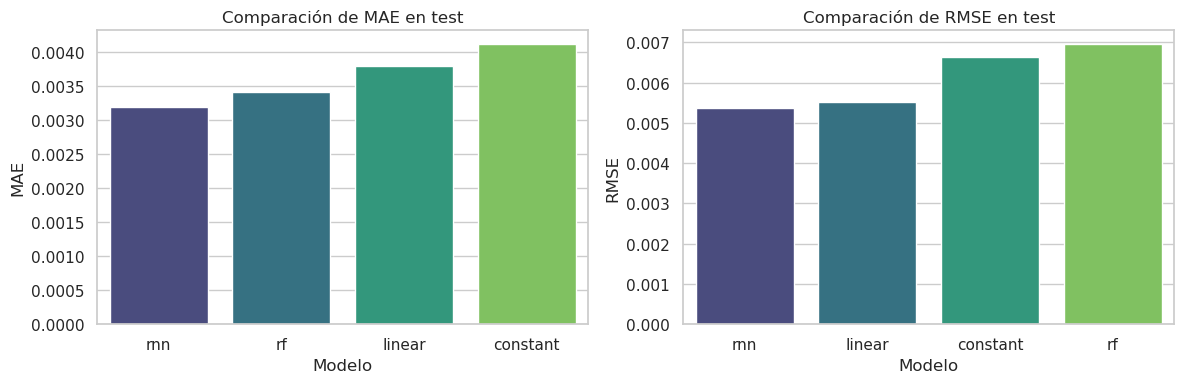

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["MAE", "RMSE"]):
    values = aligned_metrics_df.loc[metric].sort_values()
    sns.barplot(x=values.index, y=values.values, ax=ax, palette="viridis", hue=values.index, legend=False)
    ax.set_title(f"Comparación de {metric} en test")
    ax.set_xlabel("Modelo")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


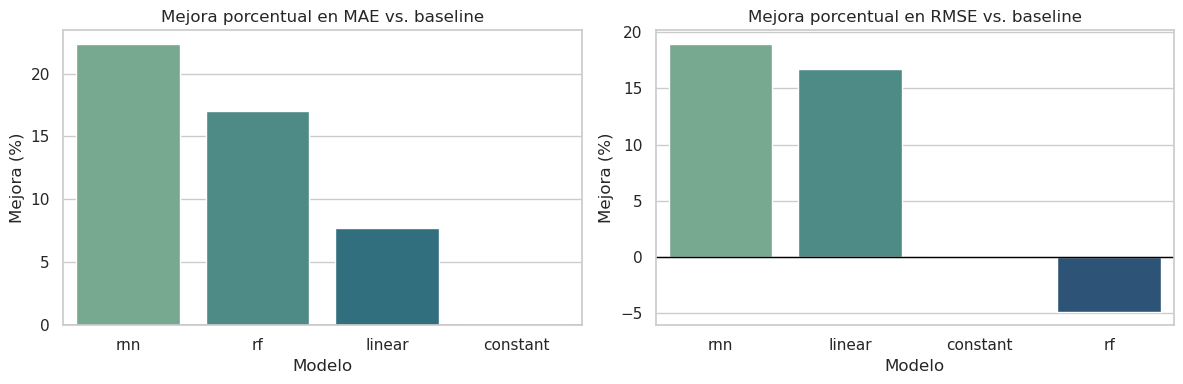

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["MAE", "RMSE"]):
    values = aligned_improvement_df.loc[metric].sort_values(ascending=False)
    sns.barplot(x=values.index, y=values.values, ax=ax, palette="crest", hue=values.index, legend=False)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Mejora porcentual en {metric} vs. baseline")
    ax.set_xlabel("Modelo")
    ax.set_ylabel("Mejora (%)")

plt.tight_layout()
plt.show()


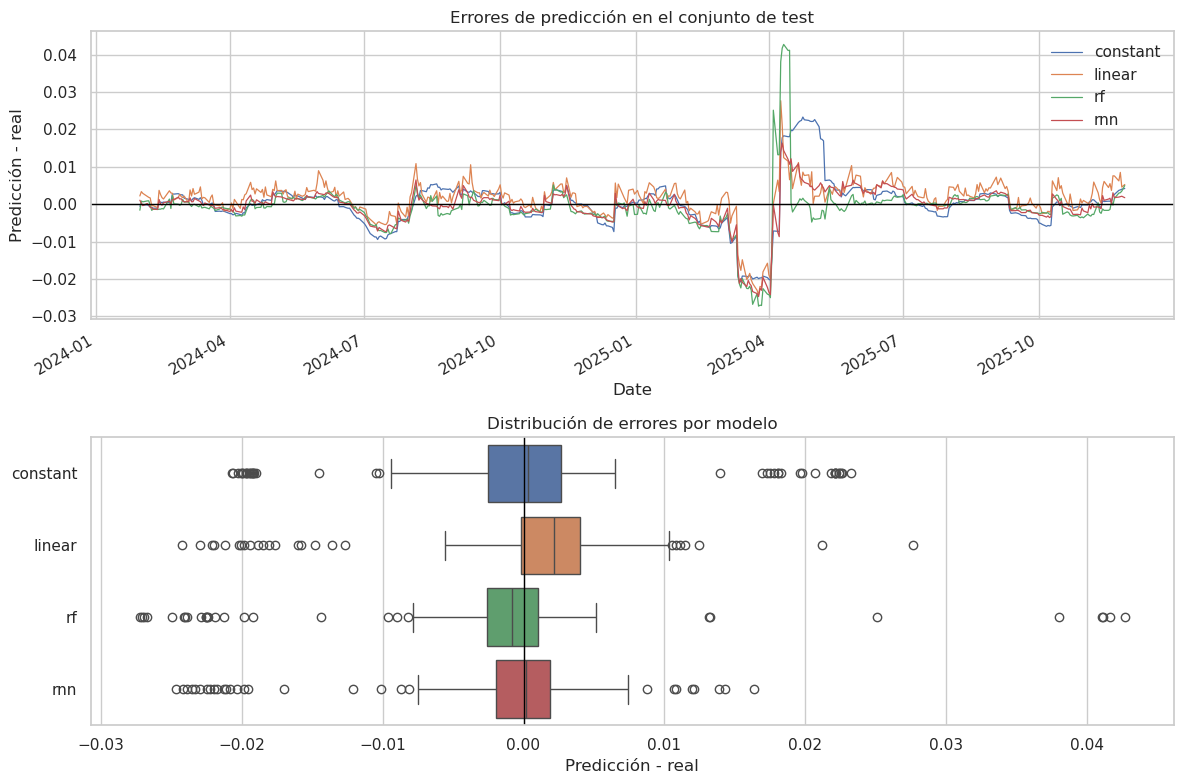

In [102]:
residuals_df = aligned_preds_df[model_cols].subtract(aligned_preds_df["target"], axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

residuals_df.plot(ax=axes[0], linewidth=0.9)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Errores de predicción en el conjunto de test")
axes[0].set_ylabel("Predicción - real")

sns.boxplot(data=residuals_df, ax=axes[1], orient="h")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Distribución de errores por modelo")
axes[1].set_xlabel("Predicción - real")

plt.tight_layout()
plt.show()


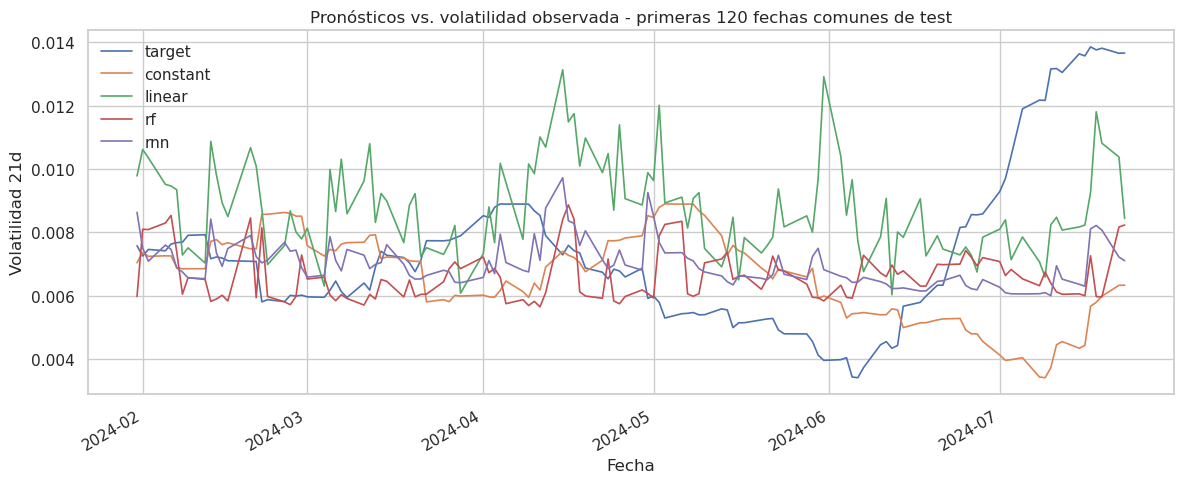

In [103]:
plot_window = aligned_preds_df.iloc[:120]

ax = plot_window[["target", "constant", "linear", "rf", "rnn"]].plot(figsize=(12, 5), linewidth=1.2)
ax.set_title("Pronósticos vs. volatilidad observada - primeras 120 fechas comunes de test")
ax.set_ylabel("Volatilidad 21d")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.show()


## Conclusiones

En este notebook se evaluaron cuatro enfoques para predecir la volatilidad a 21 días del SPY: un baseline persistente, un modelo lineal, Random Forest y una red LSTM.

El baseline persistente resultó competitivo, lo cual es esperable en volatilidad financiera por la presencia de persistencia temporal. Aun así, los modelos entrenados lograron mejorar esa referencia en distintas medidas.

El modelo lineal ofreció una mejora estable y mantuvo buena interpretabilidad. Random Forest redujo el MAE, pero su RMSE debe observarse con cautela porque penaliza errores grandes. La LSTM obtuvo el mejor desempeño global en la configuración final, con menor MAE y menor RMSE, lo que indica que pudo aprovechar información secuencial contenida en las ventanas recientes.

De todos modos, la ganancia de la LSTM frente al modelo lineal no debe interpretarse como una superioridad absoluta. El modelo recurrente es más costoso, menos interpretable y sensible a decisiones de arquitectura, escalado, longitud de ventana y entrenamiento. Por eso, el resultado más importante no es solo qué modelo gana, sino la evidencia de que la volatilidad futura contiene cierta señal temporal, aunque limitada.

En conjunto, los resultados son consistentes con la dificultad de predecir variables financieras: existen mejoras frente a un baseline razonable, pero no son mejoras masivas. La volatilidad presenta persistencia, cambios de régimen y episodios extremos que siguen siendo difíciles de anticipar usando únicamente información histórica del precio y variables derivadas.


## Graficos destacados para la presentacion

Esta seccion deja al final del notebook una version mas ejecutiva de las visualizaciones. La idea es conservar todo el desarrollo anterior, pero cerrar con los graficos mas utiles para exponer resultados de forma clara y legible.


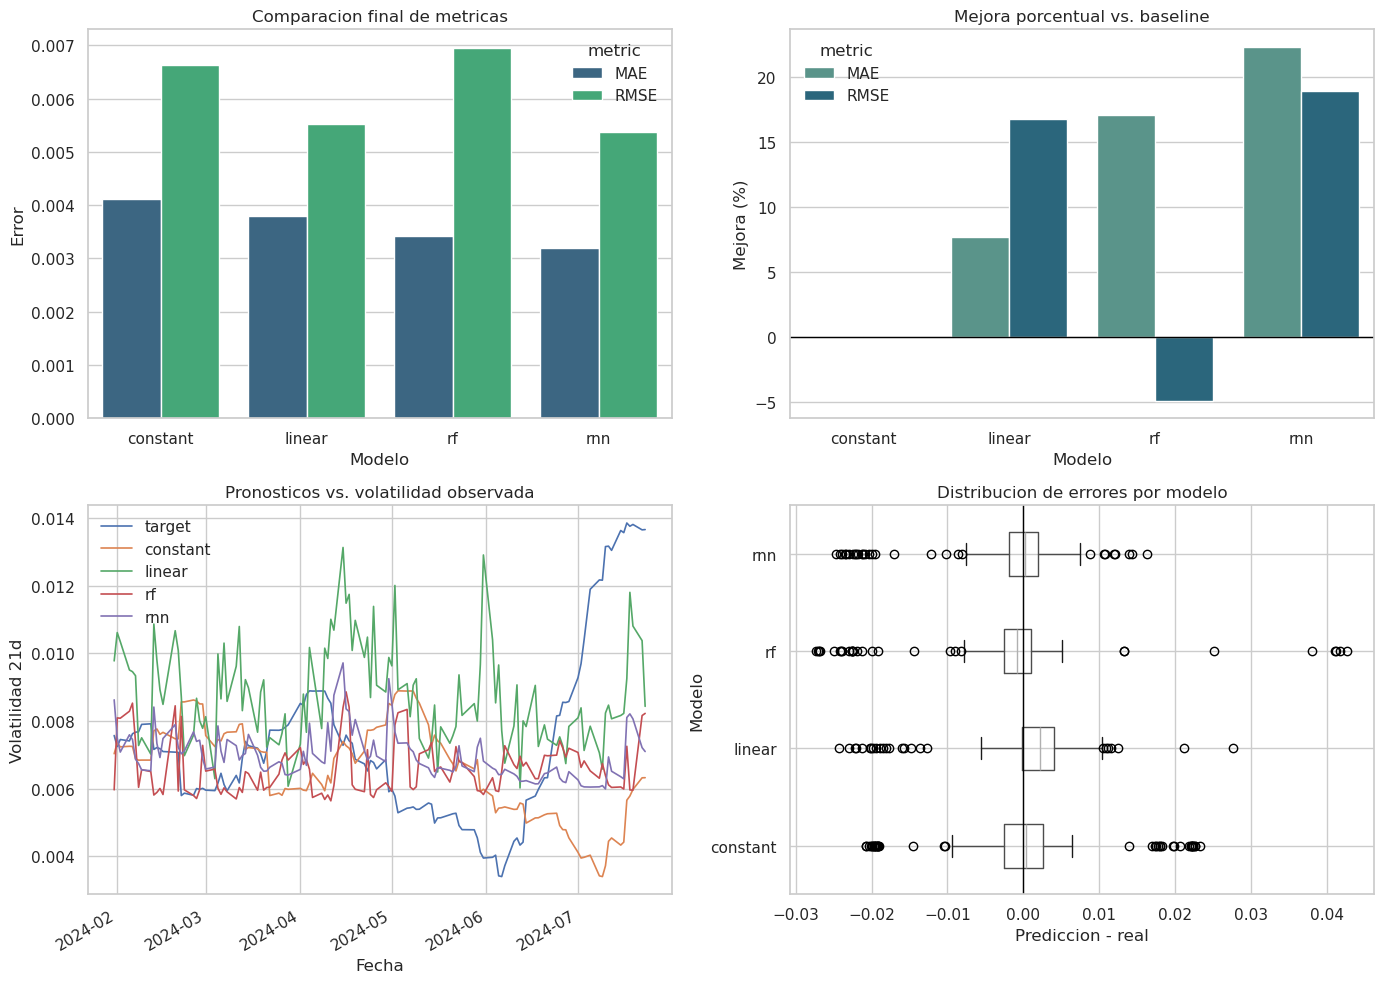

In [104]:
presentation_window = aligned_preds_df.iloc[:120].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metric_values = aligned_metrics_df.loc[["MAE", "RMSE"]].T.reset_index().rename(columns={"index": "model"})
metric_long = metric_values.melt(id_vars="model", var_name="metric", value_name="value")
sns.barplot(data=metric_long, x="model", y="value", hue="metric", ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Comparacion final de metricas")
axes[0, 0].set_xlabel("Modelo")
axes[0, 0].set_ylabel("Error")

improvement_values = aligned_improvement_df.loc[["MAE", "RMSE"]].T.reset_index().rename(columns={"index": "model"})
improvement_long = improvement_values.melt(id_vars="model", var_name="metric", value_name="value")
sns.barplot(data=improvement_long, x="model", y="value", hue="metric", ax=axes[0, 1], palette="crest")
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Mejora porcentual vs. baseline")
axes[0, 1].set_xlabel("Modelo")
axes[0, 1].set_ylabel("Mejora (%)")

presentation_window[["target", "constant", "linear", "rf", "rnn"]].plot(ax=axes[1, 0], linewidth=1.2)
axes[1, 0].set_title("Pronosticos vs. volatilidad observada")
axes[1, 0].set_xlabel("Fecha")
axes[1, 0].set_ylabel("Volatilidad 21d")

residuals_df[model_cols].boxplot(ax=axes[1, 1], vert=False)
axes[1, 1].axvline(0, color="black", linewidth=1)
axes[1, 1].set_title("Distribucion de errores por modelo")
axes[1, 1].set_xlabel("Prediccion - real")
axes[1, 1].set_ylabel("Modelo")

plt.tight_layout()
plt.show()
